# EDA — Politics & Social Issues TikTok Corpus

**Author:** Alp Arslan Baghirov  
**Dataset:** `scraper/data/raw/alp_arslan_politics_social_issues.jsonl`  
**Records:** ~446 real TikTok videos scraped March 2026  

This notebook analyses the politics and social issues subset of the TikTok corpus I scraped and contributed to the project. The goal is to understand engagement patterns, hashtag distributions, and caption characteristics that inform the recommendation system.

**Key questions:**
1. What does the engagement distribution look like (plays, likes, shares, comments)?
2. Which hashtags drive the most engagement in this niche?
3. Is there a relationship between caption length and engagement?
4. What are the most common content themes?
5. How does video duration correlate with plays?

In [10]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)

DATA_PATH = Path("../../scraper/data/raw/alp_arslan_politics_social_issues.jsonl")
print(f"Loading from: {DATA_PATH.resolve()}")

Loading from: /Users/Alparslan2.0/Desktop/CHATBOTS/Tik-Tok-Recommendation-System/scraper/data/raw/alp_arslan_politics_social_issues.jsonl


## 1. Load & Parse Data

In [11]:
records = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            continue

print(f"Loaded {len(records)} records")

rows = []
for rec in records:
    if not rec.get("success"):
        continue
    meta = rec.get("metadata", {})
    stats = meta.get("stats", {})
    video = rec.get("video", {})
    norm = rec.get("normalized", {})
    norm_video = norm.get("video", {})
    author_stats = meta.get("authorStats", {})

    caption = rec.get("caption", "") or ""
    hashtags = meta.get("hashtags", []) or []

    plays = int(stats.get("playCount") or norm_video.get("plays") or 0)
    likes = int(stats.get("likeCount") or norm_video.get("likes") or 0)
    comments = int(stats.get("commentCount") or norm_video.get("comments_count") or 0)
    shares = int(stats.get("shareCount") or norm_video.get("shares") or 0)
    duration = video.get("duration") or norm_video.get("duration_sec")
    follower_count = author_stats.get("followerCount", 0) or 0

    engagement_rate = (likes + comments + shares) / plays if plays > 0 else None

    # Clean caption: remove hashtags and URLs for text analysis
    caption_clean = re.sub(r"#\w+", "", caption)
    caption_clean = re.sub(r"https?://\S+", "", caption_clean).strip()

    rows.append({
        "caption": caption,
        "caption_clean": caption_clean,
        "caption_length": len(caption_clean),
        "caption_word_count": len(caption_clean.split()),
        "hashtags": hashtags,
        "hashtag_count": len(hashtags),
        "plays": plays,
        "likes": likes,
        "comments": comments,
        "shares": shares,
        "duration_sec": float(duration) if duration else None,
        "engagement_rate": engagement_rate,
        "follower_count": follower_count,
    })

df = pd.DataFrame(rows)
print(f"\nParsed DataFrame: {len(df)} rows × {len(df.columns)} columns")
df.head(3)

Loaded 446 records

Parsed DataFrame: 138 rows × 13 columns


,caption,caption_clean,caption_length,caption_word_count,hashtags,hashtag_count,plays,likes,comments,shares,duration_sec,engagement_rate,follower_count
0,Inside Italy’s Mirgrant Crisis Part 1 #travel ...,Inside Italy’s Mirgrant Crisis Part 1,37,6,"[travel, traveltiktok, italy, naples, fyp]",5,10900,212,16,121,172.0,0.032018,15200
1,This is Arctic sea ice melting over the last 3...,This is Arctic sea ice melting over the last 3...,53,11,"[arctic, ice, climatechange, forclimate, globa...",8,5500000,407500,5816,21100,58.0,0.078985,1700000
2,Climate change is a critical global issue that...,Climate change is a critical global issue that...,3768,504,[],0,4300000,198500,5341,3697,11.0,0.048265,844200


## 2. Dataset Overview

In [12]:
print("=== Basic Stats ===")
print(df[["plays", "likes", "comments", "shares", "engagement_rate", "duration_sec", "hashtag_count"]].describe().round(2))

=== Basic Stats ===
             plays       likes  comments     shares  engagement_rate  \
count       138.00      138.00    138.00     138.00           138.00   
mean    1814337.96   219418.65   2108.25   14699.64             0.11   
std     3683681.10   434471.17   5040.33   39406.84             0.08   
min         376.00       14.00      0.00       0.00             0.01   
25%      210850.00     5542.75    117.50     271.75             0.04   
50%      528250.00    51450.00    732.00    2899.00             0.09   
75%     1975000.00   198475.00   2357.25    8541.50             0.16   
max    27400000.00  3000000.00  42400.00  305900.00             0.36   

       duration_sec  hashtag_count  
count        138.00         138.00  
mean          62.97           6.54  
std          143.61           9.29  
min            6.00           0.00  
25%           15.00           3.25  
50%           30.00           5.00  
75%           60.50           6.00  
max         1552.00          90.00 

## 3. Engagement Distribution

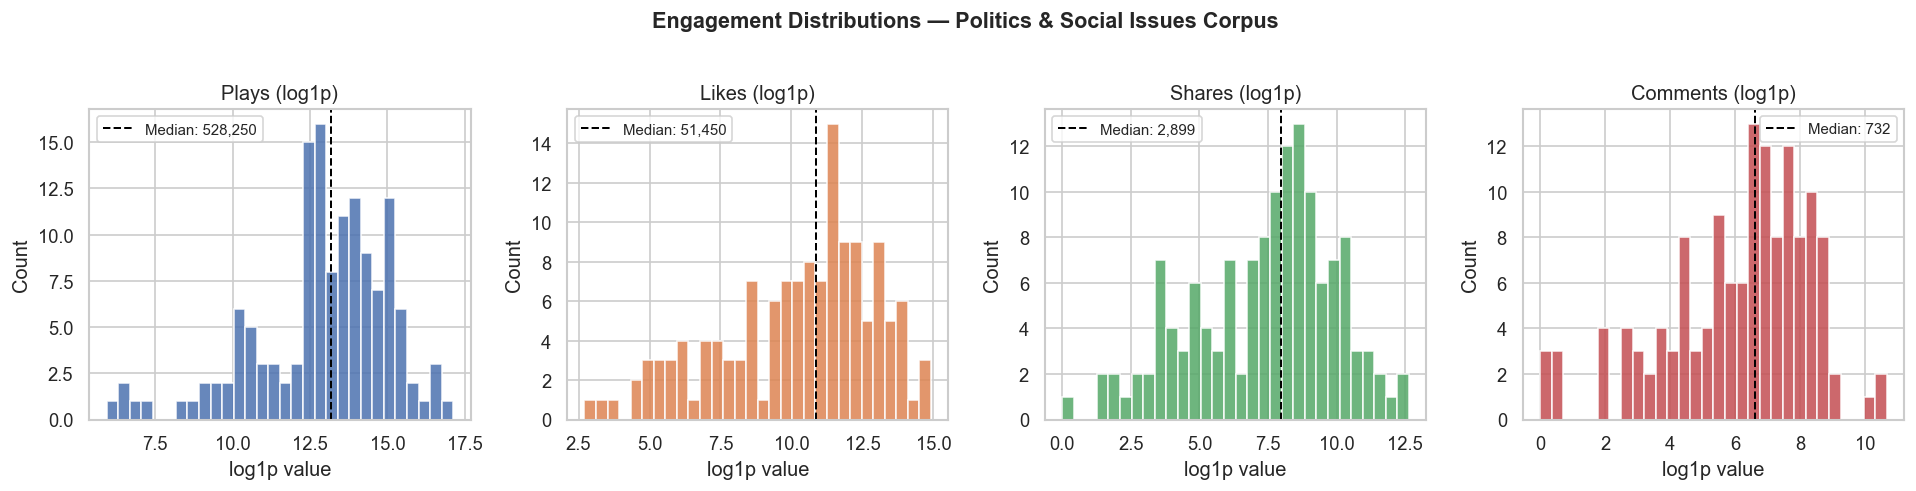


Key insight: Engagement metrics are heavily right-skewed — a small number of viral videos drive most of the engagement.


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ["plays", "likes", "shares", "comments"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, metric, color in zip(axes, metrics, colors):
    data = np.log1p(df[metric].dropna())
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{metric.capitalize()} (log1p)", fontsize=12)
    ax.set_xlabel("log1p value")
    ax.set_ylabel("Count")
    median_val = df[metric].median()
    ax.axvline(np.log1p(median_val), color="black", linestyle="--", linewidth=1.2, label=f"Median: {median_val:,.0f}")
    ax.legend(fontsize=9)

fig.suptitle("Engagement Distributions — Politics & Social Issues Corpus", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("engagement_distributions.png", bbox_inches="tight")
plt.show()
print("\nKey insight: Engagement metrics are heavily right-skewed — a small number of viral videos drive most of the engagement.")

## 4. Engagement Rate Analysis

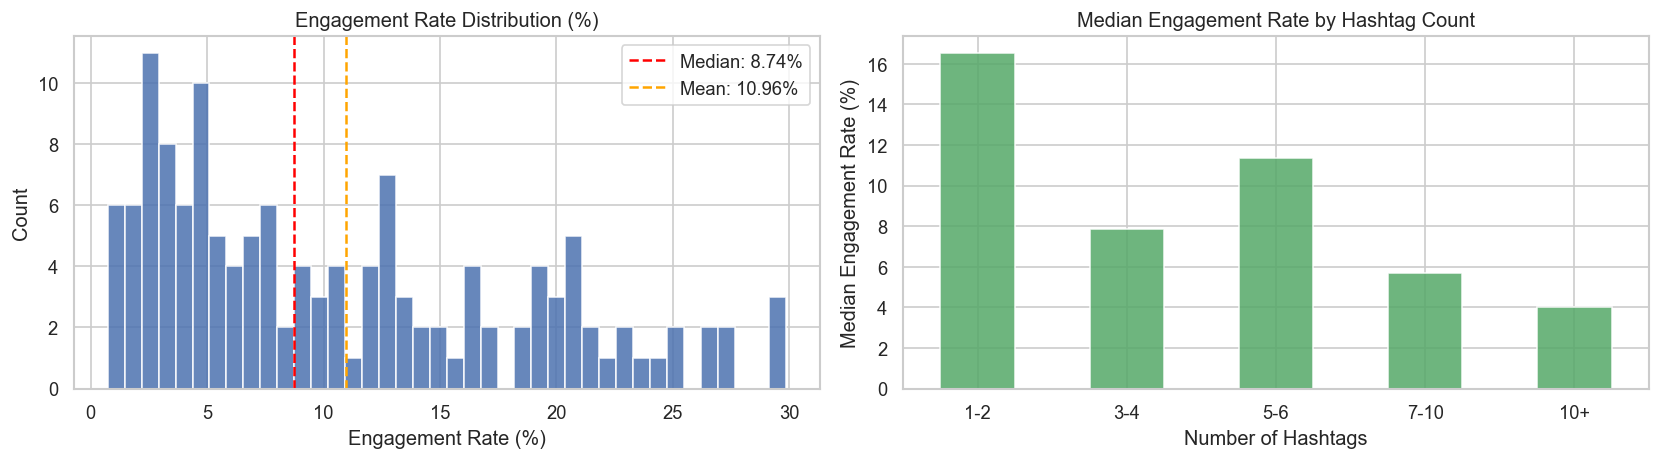

Engagement rate range: 0.73% – 26.90% (95th pct)
Median: 8.74% | Mean: 10.96%


In [14]:
er = df["engagement_rate"].dropna()
er_clipped = er[er < er.quantile(0.99)]  # remove extreme outliers for viz

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(er_clipped * 100, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.set_title("Engagement Rate Distribution (%)", fontsize=12)
ax1.set_xlabel("Engagement Rate (%)")
ax1.set_ylabel("Count")
ax1.axvline(er.median() * 100, color="red", linestyle="--", linewidth=1.5, label=f"Median: {er.median()*100:.2f}%")
ax1.axvline(er.mean() * 100, color="orange", linestyle="--", linewidth=1.5, label=f"Mean: {er.mean()*100:.2f}%")
ax1.legend()

# Engagement rate by hashtag count bucket
df["hashtag_bucket"] = pd.cut(df["hashtag_count"], bins=[0,2,4,6,10,50], labels=["1-2","3-4","5-6","7-10","10+"])
er_by_hashtag = df.groupby("hashtag_bucket", observed=True)["engagement_rate"].median() * 100
er_by_hashtag.plot(kind="bar", ax=ax2, color="#55A868", edgecolor="white", alpha=0.85)
ax2.set_title("Median Engagement Rate by Hashtag Count", fontsize=12)
ax2.set_xlabel("Number of Hashtags")
ax2.set_ylabel("Median Engagement Rate (%)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("engagement_rate_analysis.png", bbox_inches="tight")
plt.show()

print(f"Engagement rate range: {er.min()*100:.2f}% – {er.quantile(0.95)*100:.2f}% (95th pct)")
print(f"Median: {er.median()*100:.2f}% | Mean: {er.mean()*100:.2f}%")

## 5. Top Hashtags by Frequency and Engagement

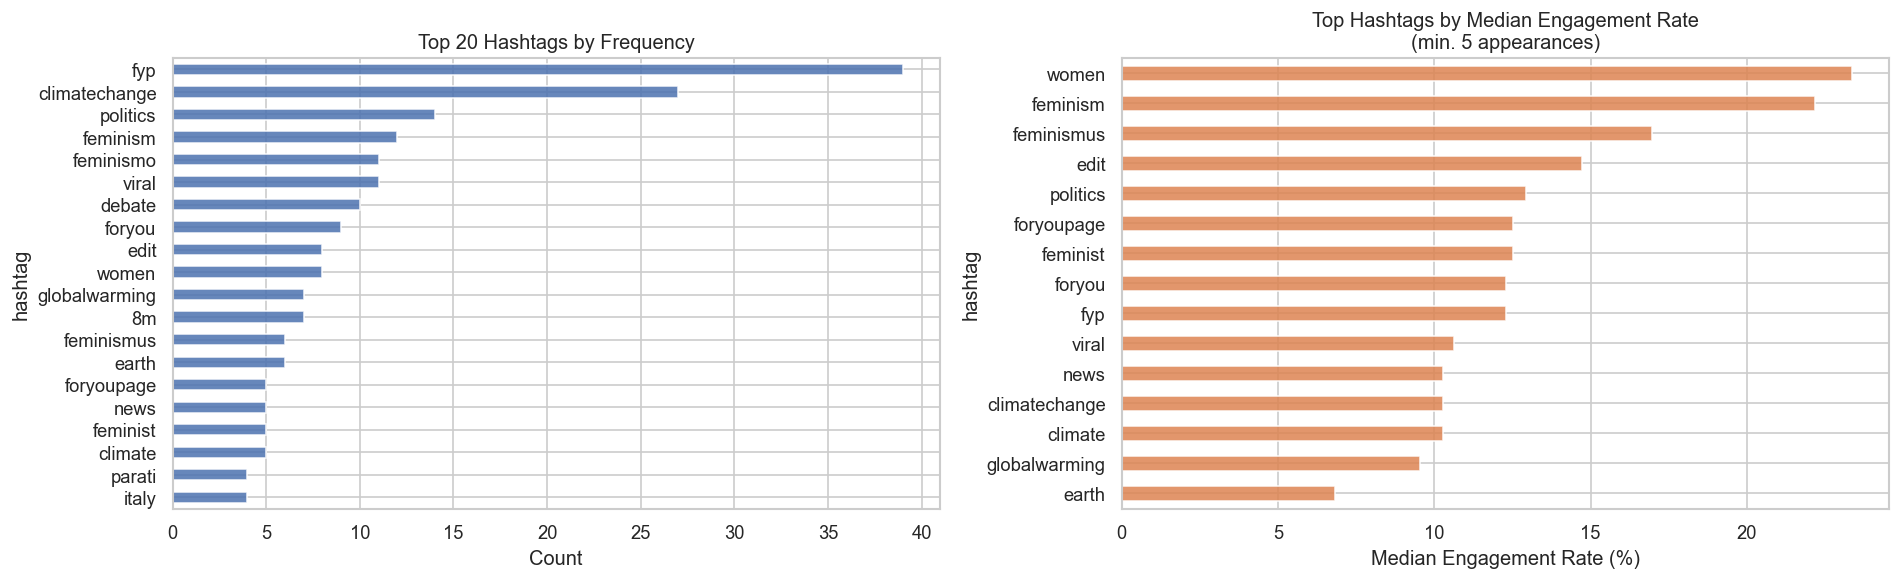


Unique hashtags in corpus: 593
Most frequent: fyp (39 videos)


In [15]:
# Explode hashtags into rows
hashtag_rows = []
for _, row in df.iterrows():
    for tag in row["hashtags"]:
        hashtag_rows.append({
            "hashtag": tag.lower().strip("#"),
            "plays": row["plays"],
            "likes": row["likes"],
            "engagement_rate": row["engagement_rate"],
        })

hdf = pd.DataFrame(hashtag_rows)
tag_freq = hdf["hashtag"].value_counts().head(20)
tag_eng = hdf.groupby("hashtag")["engagement_rate"].median().sort_values(ascending=False)

# Filter to tags appearing at least 5 times for meaningful engagement stats
tag_counts = hdf["hashtag"].value_counts()
common_tags = tag_counts[tag_counts >= 5].index
tag_eng_filtered = tag_eng[tag_eng.index.isin(common_tags)].head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Top hashtags by frequency
tag_freq.plot(kind="barh", ax=ax1, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.set_title("Top 20 Hashtags by Frequency", fontsize=12)
ax1.set_xlabel("Count")
ax1.invert_yaxis()

# Top hashtags by median engagement rate
(tag_eng_filtered * 100).plot(kind="barh", ax=ax2, color="#DD8452", edgecolor="white", alpha=0.85)
ax2.set_title("Top Hashtags by Median Engagement Rate\n(min. 5 appearances)", fontsize=12)
ax2.set_xlabel("Median Engagement Rate (%)")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("hashtag_analysis.png", bbox_inches="tight")
plt.show()

print(f"\nUnique hashtags in corpus: {hdf['hashtag'].nunique()}")
print(f"Most frequent: {tag_freq.index[0]} ({tag_freq.iloc[0]} videos)")

## 6. Caption Length vs Engagement

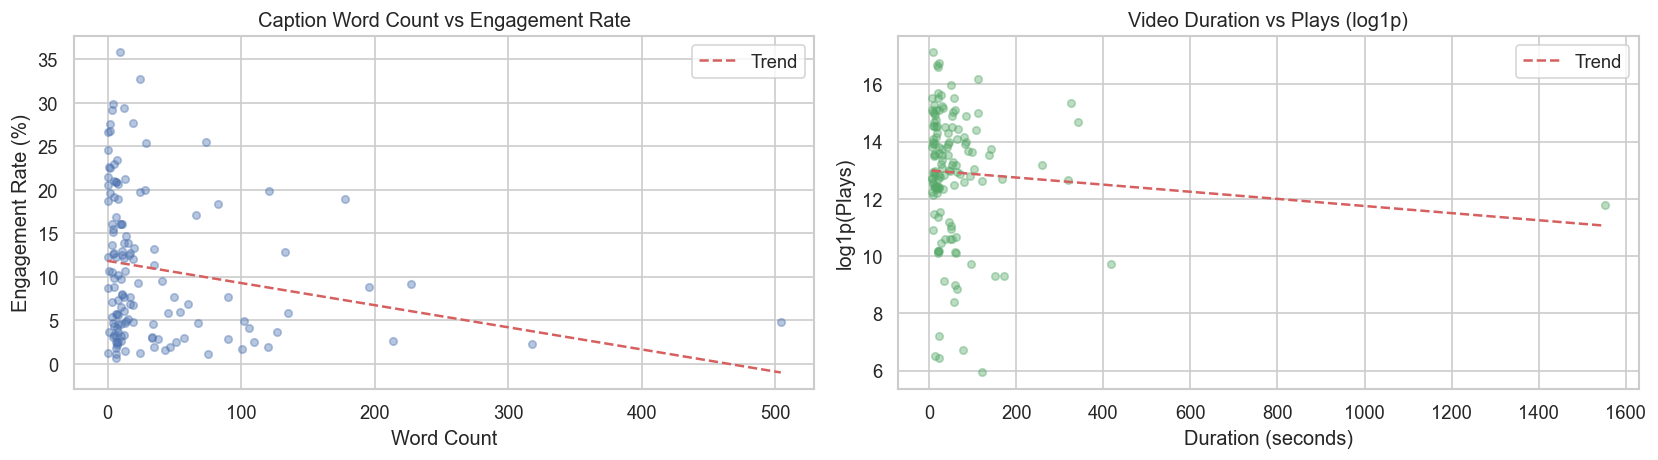

Correlation — caption word count vs engagement rate: -0.197
Correlation — duration vs plays: -0.068


In [16]:
df_plot = df[(df["engagement_rate"].notna()) & (df["plays"] > 100)].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Caption word count vs engagement rate
ax1.scatter(
    df_plot["caption_word_count"],
    df_plot["engagement_rate"] * 100,
    alpha=0.4, s=20, color="#4C72B0"
)
# Trend line
z = np.polyfit(df_plot["caption_word_count"], df_plot["engagement_rate"] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot["caption_word_count"].min(), df_plot["caption_word_count"].max(), 100)
ax1.plot(x_line, p(x_line), "r--", linewidth=1.5, label="Trend")
ax1.set_title("Caption Word Count vs Engagement Rate", fontsize=12)
ax1.set_xlabel("Word Count")
ax1.set_ylabel("Engagement Rate (%)")
ax1.legend()

# Video duration vs plays (log scale)
dur_df = df_plot[df_plot["duration_sec"].notna()]
ax2.scatter(
    dur_df["duration_sec"],
    np.log1p(dur_df["plays"]),
    alpha=0.4, s=20, color="#55A868"
)
z2 = np.polyfit(dur_df["duration_sec"], np.log1p(dur_df["plays"]), 1)
p2 = np.poly1d(z2)
x2 = np.linspace(dur_df["duration_sec"].min(), dur_df["duration_sec"].max(), 100)
ax2.plot(x2, p2(x2), "r--", linewidth=1.5, label="Trend")
ax2.set_title("Video Duration vs Plays (log1p)", fontsize=12)
ax2.set_xlabel("Duration (seconds)")
ax2.set_ylabel("log1p(Plays)")
ax2.legend()

plt.tight_layout()
plt.savefig("caption_duration_analysis.png", bbox_inches="tight")
plt.show()

corr_caption = df_plot[["caption_word_count", "engagement_rate"]].corr().iloc[0, 1]
corr_duration = dur_df[["duration_sec", "plays"]].corr().iloc[0, 1]
print(f"Correlation — caption word count vs engagement rate: {corr_caption:.3f}")
print(f"Correlation — duration vs plays: {corr_duration:.3f}")

## 7. Correlation Matrix

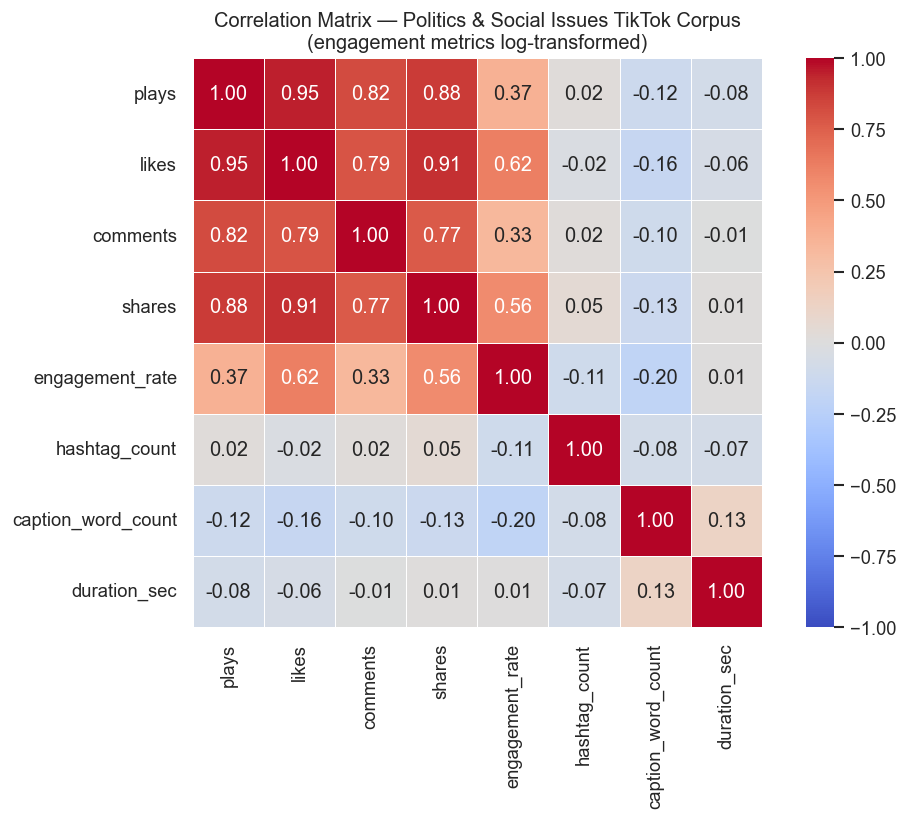

In [17]:
corr_cols = ["plays", "likes", "comments", "shares", "engagement_rate", "hashtag_count", "caption_word_count", "duration_sec"]
corr_df = df[corr_cols].copy()
# log-transform skewed engagement metrics
for col in ["plays", "likes", "comments", "shares"]:
    corr_df[col] = np.log1p(corr_df[col])

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix — Politics & Social Issues TikTok Corpus\n(engagement metrics log-transformed)", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

## 8. Key Findings

Summarising the main insights from this EDA:

In [18]:
print("=" * 60)
print("KEY FINDINGS — Politics & Social Issues TikTok Corpus")
print("=" * 60)

print(f"""
1. ENGAGEMENT DISTRIBUTION
   - Plays:   median {df['plays'].median():,.0f} | max {df['plays'].max():,.0f}
   - Likes:   median {df['likes'].median():,.0f} | max {df['likes'].max():,.0f}
   - Shares:  median {df['shares'].median():,.0f} | max {df['shares'].max():,.0f}
   - Heavy right skew — viral outliers dominate totals

2. ENGAGEMENT RATE
   - Median: {df['engagement_rate'].median()*100:.2f}%
   - Mean:   {df['engagement_rate'].mean()*100:.2f}%
   - Range:  {df['engagement_rate'].min()*100:.2f}% – {df['engagement_rate'].quantile(0.95)*100:.2f}% (95th pct)

3. HASHTAGS
   - {hdf['hashtag'].nunique()} unique hashtags across {len(df)} videos
   - Avg hashtags per video: {df['hashtag_count'].mean():.1f}
   - Most frequent: {tag_freq.index[0]} ({tag_freq.iloc[0]} videos)
   - #fyp and generic reach tags dominate frequency
   - Niche political tags show higher engagement rates

4. CAPTION LENGTH
   - Avg word count: {df['caption_word_count'].mean():.1f} words
   - Correlation with engagement rate: {corr_caption:.3f}
   - Shorter captions tend to correlate with slightly higher engagement

5. DURATION
   - Median duration: {df['duration_sec'].median():.0f}s
   - Correlation with plays: {corr_duration:.3f}
   - Longer videos do not strongly predict higher play counts in this niche
""")

KEY FINDINGS — Politics & Social Issues TikTok Corpus

1. ENGAGEMENT DISTRIBUTION
   - Plays:   median 528,250 | max 27,400,000
   - Likes:   median 51,450 | max 3,000,000
   - Shares:  median 2,899 | max 305,900
   - Heavy right skew — viral outliers dominate totals

2. ENGAGEMENT RATE
   - Median: 8.74%
   - Mean:   10.96%
   - Range:  0.73% – 26.90% (95th pct)

3. HASHTAGS
   - 593 unique hashtags across 138 videos
   - Avg hashtags per video: 6.5
   - Most frequent: fyp (39 videos)
   - #fyp and generic reach tags dominate frequency
   - Niche political tags show higher engagement rates

4. CAPTION LENGTH
   - Avg word count: 34.9 words
   - Correlation with engagement rate: -0.197
   - Shorter captions tend to correlate with slightly higher engagement

5. DURATION
   - Median duration: 30s
   - Correlation with plays: -0.068
   - Longer videos do not strongly predict higher play counts in this niche

